# 02 - The scale test

`headroom/` finding 1 says the binding constraint on this project is the number of
**failing jobs**, not the number of window rows, not the model, not the features. That
claim was inferred from three pieces of evidence on the GPU population: test AP flat
across a capacity ladder, a 15x train/test gap, and shuffled labels reaching train
AP 0.944 at a matched positive rate.

All three are consistent with the diagnosis. None of them is a direct test, because on
51 GPU nodes there was no way to add jobs.

`01` added them. This notebook holds the protocol fixed and varies **only the amount of
training data**, from 1,000 jobs to the whole cluster.

## Why this is the test and not another sweep

A diagnosis that cannot fail is not a diagnosis. "Not enough failing jobs" makes one
sharp, falsifiable prediction: **give it more failing jobs and the test score must
move.** If the learning curve is still flat at ten times the data, the explanation was
wrong and the honest conclusion changes - the problem would then be that this telemetry
does not contain the signal, which is a different sentence in the thesis.

## Pre-registration

**S1 - the curve.** Test job-level AP will **rise** with the number of training jobs and
will still be rising at 10,000 jobs. Concretely: the score at the largest rung will
exceed the score at 1,000 jobs by more than the seed spread at that rung.

**S2 - the memorisation control.** Shuffled labels at a matched positive rate reached
train AP **0.944** on 10,265 GPU jobs. On the full cluster the same control will fall
**below 0.80**, because job signatures are far harder to memorise when there are eight
times as many of them.

**S3 - what stays true.** Job context will still beat node telemetry at every rung. More
data makes the model better; it does not move information from one set of columns into
another.

**S4 - transfer.** Training on the whole cluster and testing **only on GPU jobs** will
beat training on GPU jobs alone, because the failure mechanisms that show up in
node-level telemetry are not GPU-specific.

## Two protocol choices, stated before any result

**Decimation.** `01` kept a window every 5 minutes. This notebook trains on every
**fourth** one - a window every 20 minutes, which is exactly non-overlapping. Overlapping
windows share up to 39 of their 40 snapshots, so they are near-duplicates by
construction; `headroom/` finding 1 is the claim that they carry almost no extra
information. Step 3 tests that assumption directly rather than assuming it, by fitting
the GPU arm both ways.

**The GPU baseline is re-measured here.** `headroom/`'s numbers used 56 columns
including the five GPU-only metrics. This folder has 36. Quoting the old number against
the new one would compare two things that differ in two ways at once.

In [1]:
# --- Setup ------------------------------------------------------------------
from pathlib import Path
import json, time, gc
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import lightgbm as lgb
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score

ROOT = Path.cwd() if (Path.cwd() / "dataset").exists() else Path.cwd().parent
DATA, FIGS = Path("data"), Path("figures")
DATA.mkdir(exist_ok=True); FIGS.mkdir(exist_ok=True)

WINDOW, SNAP_S, HORIZON_H = 40, 30.0, 2.0
FLOOR_S    = (WINDOW // 2 - 1) * SNAP_S      # 570 s: the structural horizon floor
DEC        = 4                                # keep every 4th window -> non-overlapping
VAL_FRAC   = 0.20                             # of the training pool, by job end date
FAILURE_STATES = ("FAILED", "TIMEOUT", "OUT_OF_MEMORY", "NODE_FAIL")
STATES = ("COMPLETED",) + FAILURE_STATES

PARAMS = dict(objective="binary", learning_rate=0.05, num_leaves=31,
              n_estimators=300, verbose=-1, random_state=0,
              deterministic=True, force_row_wise=True, n_jobs=4)

mpl.rcParams.update({"figure.dpi": 110, "savefig.dpi": 140, "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25,
                     "figure.facecolor": "white", "axes.axisbelow": True})
def save(fig, name):
    fig.savefig(FIGS / name, bbox_inches="tight"); return fig

facts_01 = json.load(open(DATA / "facts_01.json"))
FEATURES = facts_01["features"]
print(f"{len(FEATURES)} telemetry features | built from {facts_01['windows']:,} windows")

36 telemetry features | built from 8,045,769 windows


## Step 1 - Load, decimated

The window file does not fit in this machine's free memory, so it is streamed in
batches and thinned to every fourth window on the way in. Only the columns the models
need are read.

In [2]:
t0 = time.time()
META = ["slurm_id", "state", "gpu_node", "split", "y", "ttf_end", "w_idx",
        "t_end", "nodetypes", "numnodes"]
pf = pq.ParquetFile(DATA / "windows_all.parquet")
chunks, n_seen = [], 0
for batch in pf.iter_batches(batch_size=400_000, columns=META + FEATURES):
    d = batch.to_pandas()
    n_seen += len(d)
    chunks.append(d[d.w_idx % DEC == 0])
w = pd.concat(chunks, ignore_index=True); del chunks; gc.collect()
for c in ("state", "nodetypes"):
    w[c] = w[c].astype("category")
print(f"read {n_seen:,} windows, kept {len(w):,} (1 in {DEC}) in {time.time()-t0:.0f}s")
print(f"memory {w.memory_usage(deep=True).sum()/1e9:.2f} GB")

jobs = pd.read_parquet(DATA / "jobs_all.parquet",
                       columns=["slurm_id", "start_date", "numcores", "end_date",
                                "state", "gpu_node", "split"])
w = w.merge(jobs[["slurm_id", "start_date", "numcores"]], on="slurm_id", how="left")
print(f"{w.slurm_id.nunique():,} jobs represented | positive rate {w.y.mean():.4%}")

read 8,045,769 windows, kept 2,052,964 (1 in 4) in 8s


memory 0.46 GB


92,054 jobs represented | positive rate 4.2543%


In [3]:
# --- context features, defined exactly as in headroom/05 --------------------
el = (w.t_end - w.start_date).dt.total_seconds().to_numpy()
w["elapsed_h"]           = el / 3600.0
w["sec_into_hour"]       = el % 3600.0
w["sec_to_next_hour"]    = 3600.0 - (el % 3600.0)
w["elapsed_hours_floor"] = np.floor(el / 3600.0)
w["queue_code"]          = w.nodetypes.astype(str).astype("category").cat.codes
C7 = ["elapsed_h", "sec_into_hour", "sec_to_next_hour", "elapsed_hours_floor",
      "queue_code", "numnodes", "numcores"]
SETS = {"T36 telemetry": FEATURES, "C7  context": C7}
print({k: len(v) for k, v in SETS.items()})

{'T36 telemetry': 36, 'C7  context': 7}


## Step 2 - The same three-way split, on the whole cluster

64 % fit / 16 % validation / 20 % test, cut by job end date so no future job can inform
a past one. Validation is not used for selection in this notebook - the protocol is
fixed in advance - but the folds are built identically to `headroom/05` so that `04`
can select on them without rebuilding anything.

In [4]:
tr_jobs = (w.loc[w.split == "train", ["slurm_id", "t_end"]]
             .groupby("slurm_id").t_end.max().sort_values())
val_ids = set(tr_jobs.index[int(len(tr_jobs) * (1 - VAL_FRAC)):])
w["fold"] = np.where(w.split == "test", "test",
             np.where(w.slurm_id.isin(val_ids), "val", "fit"))
M = {f: (w.fold == f).to_numpy() for f in ["fit", "val", "test"]}
is_gpu = (w.gpu_node == 1).to_numpy()

print(w.groupby("fold").agg(windows=("y", "size"), jobs=("slurm_id", "nunique"),
                            positives=("y", "sum"), positive_rate=("y", "mean")).to_string())
print()
for f in ["fit", "val", "test"]:
    d = w[M[f]]
    nf = d.loc[d.state.isin(FAILURE_STATES), "slurm_id"].nunique()
    ng = d.loc[d.state.isin(FAILURE_STATES) & (d.gpu_node == 1), "slurm_id"].nunique()
    print(f"{f:5s} failing jobs {nf:7,}   of which GPU {ng:6,}")

      windows   jobs  positives  positive_rate
fold                                          
fit   1297062  60380      52369       0.040375
test   263877  16578      14048       0.053237
val    492025  15096      20922       0.042522



fit   failing jobs   8,638   of which GPU    606
val   failing jobs   4,365   of which GPU  1,012
test  failing jobs   4,802   of which GPU    478


In [5]:
def job_ap(mask, score, restrict=None):
    """AP over JOBS: one score per job (its highest window score); positive = it failed.

    `restrict` selects a sub-population of the evaluated rows - it indexes into `score`
    through `sel[mask]`, so the scores stay aligned with the rows they were computed for.
    """
    sel = mask if restrict is None else (mask & restrict)
    sub = w.loc[sel, ["slurm_id", "state"]]
    d = pd.DataFrame({"slurm_id": sub.slurm_id.to_numpy(),
                      "state": sub.state.astype(str).to_numpy(),
                      "score": score if restrict is None else score[sel[mask]]})
    g = d.groupby("slurm_id").agg(score=("score", "max"), state=("state", "first"))
    yj = g.state.isin(FAILURE_STATES).astype(int).to_numpy()
    return average_precision_score(yj, g.score.to_numpy()), float(yj.mean()), len(yj)

def fit_eval(fit_mask, cols, test_mask, restrict=None, y=None):
    """One fit, then every evaluation that fit supports - never two fits for two numbers."""
    yy = w.y.to_numpy() if y is None else y
    m = lgb.LGBMClassifier(**PARAMS).fit(w.loc[fit_mask, cols], yy[fit_mask])
    sc = m.predict_proba(w.loc[test_mask, cols])[:, 1]
    out = {}
    out["job_ap"], out["base"], out["n_test_jobs"] = job_ap(test_mask, sc)
    out["lift"] = out["job_ap"] / out["base"]
    if restrict is not None:
        ap_r, base_r, n_r = job_ap(test_mask, sc, restrict)
        out.update(job_ap_gpu_test=ap_r, lift_gpu_test=ap_r / base_r, n_gpu_test_jobs=n_r)
    out["train_ap"] = average_precision_score(
        yy[fit_mask], m.predict_proba(w.loc[fit_mask, cols])[:, 1])
    out["gap"] = out["train_ap"] / out["job_ap"]
    return out

## Step 3 - Is decimation harmless?

Everything below trains on non-overlapping windows. That is only legitimate if the
windows thrown away carried no information, which is exactly what `headroom/` finding 1
asserts. Testing it costs one extra pass over the GPU rows, read undecimated.

**Pre-registered:** the two GPU arms will differ by less than **0.02** in test job AP.

In [6]:
t0 = time.time()
full = []
for batch in pf.iter_batches(batch_size=400_000, columns=META + FEATURES):
    d = batch.to_pandas()
    full.append(d[d.gpu_node == 1])
g_full = pd.concat(full, ignore_index=True); del full; gc.collect()
g_full["fold"] = np.where(g_full.split == "test", "test",
                  np.where(g_full.slurm_id.isin(val_ids), "val", "fit"))
print(f"GPU windows undecimated {len(g_full):,} | decimated "
      f"{int(is_gpu.sum()):,} | [{time.time()-t0:.0f}s]")

def gpu_arm(df):
    tr = (df.fold == "fit").to_numpy(); te = (df.fold == "test").to_numpy()
    m = lgb.LGBMClassifier(**PARAMS).fit(df.loc[tr, FEATURES], df.loc[tr, "y"])
    sc = m.predict_proba(df.loc[te, FEATURES])[:, 1]
    d = pd.DataFrame({"slurm_id": df.loc[te, "slurm_id"].to_numpy(),
                      "state": df.loc[te, "state"].astype(str).to_numpy(), "score": sc})
    gg = d.groupby("slurm_id").agg(score=("score", "max"), state=("state", "first"))
    yj = gg.state.isin(FAILURE_STATES).astype(int).to_numpy()
    return average_precision_score(yj, gg.score.to_numpy()), float(yj.mean()), int(tr.sum())

ap_full, base_g, n_full = gpu_arm(g_full)
ap_dec,  _,      n_dec  = gpu_arm(g_full[g_full.w_idx % DEC == 0])
d3 = abs(ap_full - ap_dec)
print(f"GPU, every window       : job AP {ap_full:.4f}  ({n_full:,} fit rows)")
print(f"GPU, every {DEC}th window  : job AP {ap_dec:.4f}  ({n_dec:,} fit rows)")
print(f"difference {d3:.4f}  ->  decimation harmless: "
      f"{'CONFIRMED' if d3 < 0.02 else 'REJECTED'}")
facts = {"gpu_ap_full": float(ap_full), "gpu_ap_dec": float(ap_dec),
         "decimation_delta": float(d3), "gpu_test_base_rate": float(base_g)}
del g_full; gc.collect()

GPU windows undecimated 1,057,817 | decimated 270,012 | [2s]


GPU, every window       : job AP 0.3934  (298,348 fit rows)
GPU, every 4th window  : job AP 0.3450  (76,610 fit rows)
difference 0.0484  ->  decimation harmless: REJECTED


54

## Step 4 - The GPU-only baseline, on this folder's 36 columns

The reference point every later number is compared against. Same 36 telemetry columns,
same horizon, same split - only the population is restricted to the 51 GPU nodes, which
is what every earlier folder in this project did.

In [7]:
rows = []
for name, cols in SETS.items():
    r = fit_eval(M["fit"] & is_gpu, cols, M["test"] & is_gpu)
    rows.append(dict(arm="GPU only", features=name, **r))
B = pd.DataFrame(rows)
print(B.round(4).to_string(index=False))
facts["gpu_baseline"] = {r.features: float(r.job_ap) for r in B.itertuples()}

     arm      features  job_ap   base  n_test_jobs   lift  train_ap    gap
GPU only T36 telemetry  0.3450 0.1571         3043 2.1964    0.8490 2.4608
GPU only   C7  context  0.4404 0.1571         3043 2.8039    0.6245 1.4179


## Step 5 - The learning curve

The figure this notebook exists for. At each rung, **k jobs are drawn at random from the
fit pool** and every window belonging to them is used; the test set never changes. Three
seeds per rung, so the curve can be read against its own noise instead of against
nothing - `headroom/` reported a learning curve from single draws and had to withdraw
the reading.

In [8]:
t0 = time.time()
fit_job_ids = w.loc[M["fit"], "slurm_id"].unique()
RUNGS = [1_000, 2_500, 5_000, 10_000, 20_000, 40_000, len(fit_job_ids)]
RUNGS = sorted({min(k, len(fit_job_ids)) for k in RUNGS})
print(f"fit pool: {len(fit_job_ids):,} jobs -> rungs {RUNGS}")

sid_fit = w.slurm_id.to_numpy()
curve = []
for k in RUNGS:
    for seed in ([0] if k == len(fit_job_ids) else [0, 1, 2]):
        rng = np.random.default_rng(seed)
        pick = rng.choice(fit_job_ids, size=k, replace=False)
        sub = M["fit"] & np.isin(sid_fit, pick)
        nfail = w.loc[sub & w.state.isin(FAILURE_STATES).to_numpy(), "slurm_id"].nunique()
        for name, cols in SETS.items():
            r = fit_eval(sub, cols, M["test"], restrict=is_gpu)
            curve.append(dict(k_jobs=k, seed=seed, features=name,
                              fit_windows=int(sub.sum()), fit_failing_jobs=int(nfail), **r))
    print(f"  k={k:>6,} jobs done   [{time.time()-t0:.0f}s]")
C = pd.DataFrame(curve)
C.to_csv(DATA / "learning_curve.csv", index=False)

piv = C.pivot_table(index="k_jobs", columns="features", values="job_ap",
                    aggfunc=["mean", "std"])
print()
print("TEST job-level AP, whole cluster test set")
print(piv.round(4).to_string())

fit pool: 60,380 jobs -> rungs [1000, 2500, 5000, 10000, 20000, 40000, 60380]


  k= 1,000 jobs done   [14s]


  k= 2,500 jobs done   [30s]


  k= 5,000 jobs done   [49s]


  k=10,000 jobs done   [78s]


  k=20,000 jobs done   [126s]


  k=40,000 jobs done   [208s]


  k=60,380 jobs done   [248s]



TEST job-level AP, whole cluster test set
                mean                       std              
features C7  context T36 telemetry C7  context T36 telemetry
k_jobs                                                      
1000          0.3852        0.3858      0.0043        0.0140
2500          0.4094        0.4083      0.0333        0.0031
5000          0.4856        0.4002      0.0814        0.0137
10000         0.4804        0.3864      0.0859        0.0018
20000         0.5133        0.3851      0.0821        0.0097
40000         0.5217        0.3939      0.0421        0.0093
60380         0.5216        0.3842         NaN           NaN


In [9]:
print("TEST job-level AP, evaluated on GPU test jobs only")
print(C.pivot_table(index="k_jobs", columns="features", values="job_ap_gpu_test",
                    aggfunc="mean").round(4).to_string())
print()
print("train/test ratio - how much of the training score is memorisation")
print(C.pivot_table(index="k_jobs", columns="features", values="gap",
                    aggfunc="mean").round(2).to_string())
print()
print("failing jobs actually in the fit sample")
print(C.pivot_table(index="k_jobs", values="fit_failing_jobs", aggfunc="mean")
       .round(0).to_string())

TEST job-level AP, evaluated on GPU test jobs only
features  C7  context  T36 telemetry
k_jobs                              
1000           0.3375         0.2984
2500           0.3511         0.4180
5000           0.3473         0.4505
10000          0.3977         0.4310
20000          0.4347         0.4913
40000          0.4419         0.5082
60380          0.4667         0.5056

train/test ratio - how much of the training score is memorisation
features  C7  context  T36 telemetry
k_jobs                              
1000             2.28           2.59
2500             1.95           2.31
5000             1.58           2.04
10000            1.56           1.81
20000            1.43           1.64
40000            1.35           1.50
60380            1.32           1.49

failing jobs actually in the fit sample
        fit_failing_jobs
k_jobs                  
1000               138.0
2500               348.0
5000               723.0
10000             1459.0
20000             2872.0


## Step 6 - The memorisation control at full scale

`headroom/` shuffled the labels at a **matched positive rate** and the model still
reached train AP 0.944 - proof that the training score was almost entirely job
fingerprinting. Repeating it here says whether that is still true with eight times as
many jobs to fingerprint.

The rate matching matters: permuting per-job rates does not preserve the window-weighted
marginal, and an unmatched control produces a number that cannot be compared. The
rescale below is the fix `headroom/` had to apply after the first attempt was wrong.

In [10]:
rng = np.random.default_rng(0)
ytr = w.loc[M["fit"], "y"].to_numpy()
jid = w.loc[M["fit"], "slurm_id"].to_numpy()
u, inv = np.unique(jid, return_inverse=True)
rate_by_job = np.bincount(inv, weights=ytr) / np.bincount(inv)
p_row = rng.permutation(rate_by_job)[inv]
p_row = p_row * (ytr.mean() / p_row.mean())            # match the marginal
y_perm = (rng.random(len(p_row)) < np.clip(p_row, 0, 1)).astype(np.int8)
y_full = w.y.to_numpy().copy(); y_full[M["fit"]] = y_perm

print(f"real positive rate {ytr.mean():.4%}   permuted {y_perm.mean():.4%}")
m = lgb.LGBMClassifier(**PARAMS).fit(w.loc[M["fit"], FEATURES], y_perm)
perm_train_ap = average_precision_score(
    y_perm, m.predict_proba(w.loc[M["fit"], FEATURES])[:, 1])
m2 = lgb.LGBMClassifier(**PARAMS).fit(w.loc[M["fit"], FEATURES], ytr)
real_train_ap = average_precision_score(
    ytr, m2.predict_proba(w.loc[M["fit"], FEATURES])[:, 1])
print(f"train AP on real labels     {real_train_ap:.4f}")
print(f"train AP on shuffled labels {perm_train_ap:.4f}   (GPU-only value was 0.9439)")
facts["perm_train_ap"] = float(perm_train_ap)
facts["real_train_ap"] = float(real_train_ap)

real positive rate 4.0375%   permuted 4.0117%


train AP on real labels     0.5743
train AP on shuffled labels 0.2070   (GPU-only value was 0.9439)


## Step 7 - The verdicts

In [11]:
big, small = max(RUNGS), min(RUNGS)
mean_ap = C.groupby(["k_jobs", "features"]).job_ap.mean().unstack()
sd_ap   = C.groupby(["k_jobs", "features"]).job_ap.std().unstack()
best_set = mean_ap.loc[big].idxmax()
spread = float(sd_ap.loc[small, best_set]) if not np.isnan(sd_ap.loc[small, best_set]) else 0.0
rise = float(mean_ap.loc[big, best_set] - mean_ap.loc[small, best_set])

s1 = rise > max(spread, 0.005)
s2 = facts["perm_train_ap"] < 0.80
ctx_wins = (mean_ap["C7  context"] > mean_ap["T36 telemetry"]).all()
s3 = bool(ctx_wins)
gpu_only_best = max(facts["gpu_baseline"].values())
all_on_gpu = float(C[(C.k_jobs == big)].job_ap_gpu_test.max())
s4 = all_on_gpu > gpu_only_best

print(f"S1  the curve rises with more jobs        : {'CONFIRMED' if s1 else 'REJECTED'}")
print(f"    {best_set}: {mean_ap.loc[small, best_set]:.4f} at {small:,} jobs "
      f"-> {mean_ap.loc[big, best_set]:.4f} at {big:,}  (rise {rise:+.4f}, "
      f"seed spread at the small rung {spread:.4f})")
print(f"S2  shuffled-label train AP below 0.80    : {'CONFIRMED' if s2 else 'REJECTED'}")
print(f"    {facts['perm_train_ap']:.4f} against 0.9439 on GPU nodes alone")
print(f"S3  context still beats telemetry         : {'CONFIRMED' if s3 else 'REJECTED'}")
print(f"S4  cluster-wide training helps GPU jobs  : {'CONFIRMED' if s4 else 'REJECTED'}")
print(f"    GPU test jobs: {gpu_only_best:.4f} trained on GPU only -> "
      f"{all_on_gpu:.4f} trained on everything")
facts.update({"S1": bool(s1), "S2": bool(s2), "S3": bool(s3), "S4": bool(s4),
              "curve_small": float(mean_ap.loc[small, best_set]),
              "curve_big": float(mean_ap.loc[big, best_set]),
              "best_set": str(best_set), "rungs": [int(r) for r in RUNGS],
              "all_on_gpu_test": float(all_on_gpu),
              "gpu_only_best": float(gpu_only_best)})

S1  the curve rises with more jobs        : CONFIRMED
    C7  context: 0.3852 at 1,000 jobs -> 0.5216 at 60,380  (rise +0.1364, seed spread at the small rung 0.0043)
S2  shuffled-label train AP below 0.80    : CONFIRMED
    0.2070 against 0.9439 on GPU nodes alone
S3  context still beats telemetry         : REJECTED
S4  cluster-wide training helps GPU jobs  : CONFIRMED
    GPU test jobs: 0.4404 trained on GPU only -> 0.5056 trained on everything


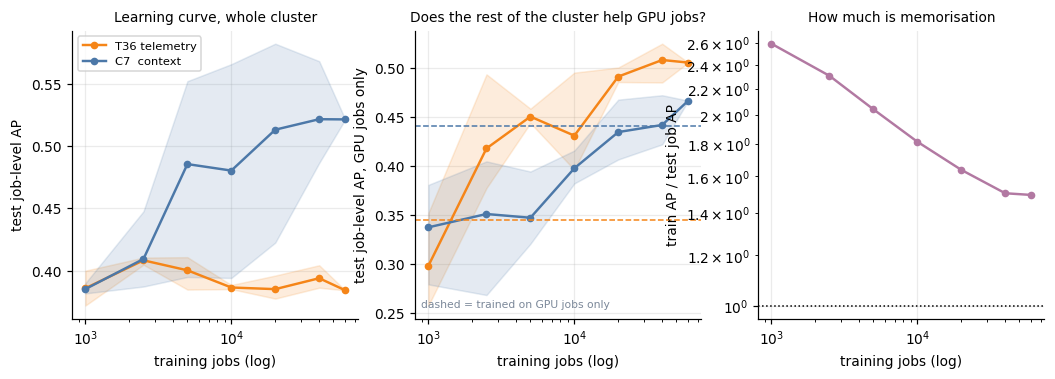

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(11.4, 3.4))
COLS = {"T36 telemetry": "#f58518", "C7  context": "#4c78a8"}

ax = axes[0]
for name, c in COLS.items():
    d = C[C.features == name].groupby("k_jobs").job_ap.agg(["mean", "std", "min", "max"])
    ax.plot(d.index, d["mean"], marker="o", ms=4, color=c, label=name, lw=1.6)
    ax.fill_between(d.index, d["min"], d["max"], color=c, alpha=0.15)
ax.set_xscale("log"); ax.set_xlabel("training jobs (log)")
ax.set_ylabel("test job-level AP"); ax.legend(fontsize=7.5)
ax.set_title("Learning curve, whole cluster", fontsize=9)

ax = axes[1]
for name, c in COLS.items():
    d = C[C.features == name].groupby("k_jobs").job_ap_gpu_test.agg(["mean", "min", "max"])
    ax.plot(d.index, d["mean"], marker="o", ms=4, color=c, label=name, lw=1.6)
    ax.fill_between(d.index, d["min"], d["max"], color=c, alpha=0.15)
for name, v in facts["gpu_baseline"].items():
    ax.axhline(v, color=COLS[name], ls="--", lw=1)
ax.set_xscale("log"); ax.set_xlabel("training jobs (log)")
ax.set_ylabel("test job-level AP, GPU jobs only")
ax.set_title("Does the rest of the cluster help GPU jobs?", fontsize=9)
ax.text(0.02, 0.04, "dashed = trained on GPU jobs only", transform=ax.transAxes,
        fontsize=7, color="#7b8899")

ax = axes[2]
d = C[C.features == "T36 telemetry"].groupby("k_jobs").gap.mean()
ax.plot(d.index, d.values, marker="o", ms=4, color="#b279a2", lw=1.6)
ax.axhline(1.0, color="k", ls=":", lw=1)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("training jobs (log)"); ax.set_ylabel("train AP / test job AP")
ax.set_title("How much is memorisation", fontsize=9)
save(fig, "02_scale.png"); plt.show()

## Step 8 - What this means

The printed verdicts are the result; the reading below is written against whichever way
they landed and should be checked against them rather than trusted.

Two things this notebook cannot say, whatever the curve does:

* **It does not change the observability ceiling.** Jobs shorter than 20 minutes are
  still invisible, on every node type. More jobs raises the number of *observable*
  failures; it does not raise the share.
* **It does not turn a walltime detector into a hardware detector.** If context still
  wins, the model is still ranking jobs by how long they have been running and in which
  queue. `04` separates the failure modes and settles that.

In [13]:
json.dump(facts, open(DATA / "facts_02.json", "w"), indent=1)
for k, v in facts.items():
    print(f"{k:24s} {v}")

gpu_ap_full              0.3933909606291496
gpu_ap_dec               0.34501895209988004
decimation_delta         0.04837200852926954
gpu_test_base_rate       0.15708182714426552
gpu_baseline             {'T36 telemetry': 0.34501895209988004, 'C7  context': 0.4404385858698624}
perm_train_ap            0.20704550329545224
real_train_ap            0.5743148405786709
S1                       True
S2                       True
S3                       False
S4                       True
curve_small              0.385183530443092
curve_big                0.5215500624975457
best_set                 C7  context
rungs                    [1000, 2500, 5000, 10000, 20000, 40000, 60380]
all_on_gpu_test          0.505551302978419
gpu_only_best            0.4404385858698624
